In [1]:
import numpy as np
import matplotlib.ticker as tkr
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from matplotlib import colors
from figures_functions import *
from matplotlib.lines import Line2D

## read saved files

In [2]:
wnep=xr.open_dataset('~/ResultsCS/Weights/nepCMIP6_ob_FLUXCOM-X.nc') # weights CMIP6-FLUXCOM-X.
wnbp=xr.open_dataset('~/ResultsCS/Weights/nbpCMIP6_ob_CarboScope.nc')  # weights CMIP6-CarboScope
vnep=xr.open_dataset('~/ResultsCS/Weights/nepCMIP6_ob_FLUXCOM-X_variance.nc') # variance CMIP6-FLUXCOM-X
vnbp=xr.open_dataset('~/ResultsCS/Weights/nbpCMIP6_ob_CarboScope_variance.nc')  # variance CMIP6-CarboScope
Amnep=xr.open_dataset('~/ResultsCS/Weights/nepCMIP6_ob_FLUXCOM-X_Amin.nc') # Amin CMIP6-FLUXCOM-X.
Amnbp=xr.open_dataset('~/ResultsCS/Weights/nbpCMIP6_ob_CarboScope_Amin.nc')  # Amin CMIP6-CarboScope
Dnep=xr.open_dataset('~/ResultsCS/Weights/nepCMIP6_ob_FLUXCOM-X_D.nc') # Amin CMIP6-FLUXCOM-X.
Dnbp=xr.open_dataset('~/ResultsCS/Weights/nbpCMIP6_ob_CarboScope_D.nc')  # Amin CMIP6-CarboScope


/home/_ehoyos/anaconda3/lib/python3.9/site-packages/xarray/backends/plugins.py:71: RuntimeWarning: Engine 'gini' loading failed:
cannot import name 'deprecated' from 'typing_extensions' (/home/_ehoyos/anaconda3/lib/python3.9/site-packages/typing_extensions.py)
  warnings.warn(f"Engine {name!r} loading failed:\n{ex}", RuntimeWarning)


In [3]:
model=['BCC-CSM2-MR','CanESM5','CNRM-ESM2-1','ACCESS-ESM1-5','UKESM1-0-LL','MPI-ESM1-2-LR','CESM2','NorESM2-LM','NOAA-GFDL-ESM4']
modelnep=model.copy(); modelnep.remove('CESM2')
modelnbp=model.copy(); modelnbp.remove('BCC-CSM2-MR')


## CMIP6-FLUXCOM-X

In [190]:
np.linspace(0,1,15)

array([0.        , 0.07142857, 0.14285714, 0.21428571, 0.28571429,
       0.35714286, 0.42857143, 0.5       , 0.57142857, 0.64285714,
       0.71428571, 0.78571429, 0.85714286, 0.92857143, 1.        ])

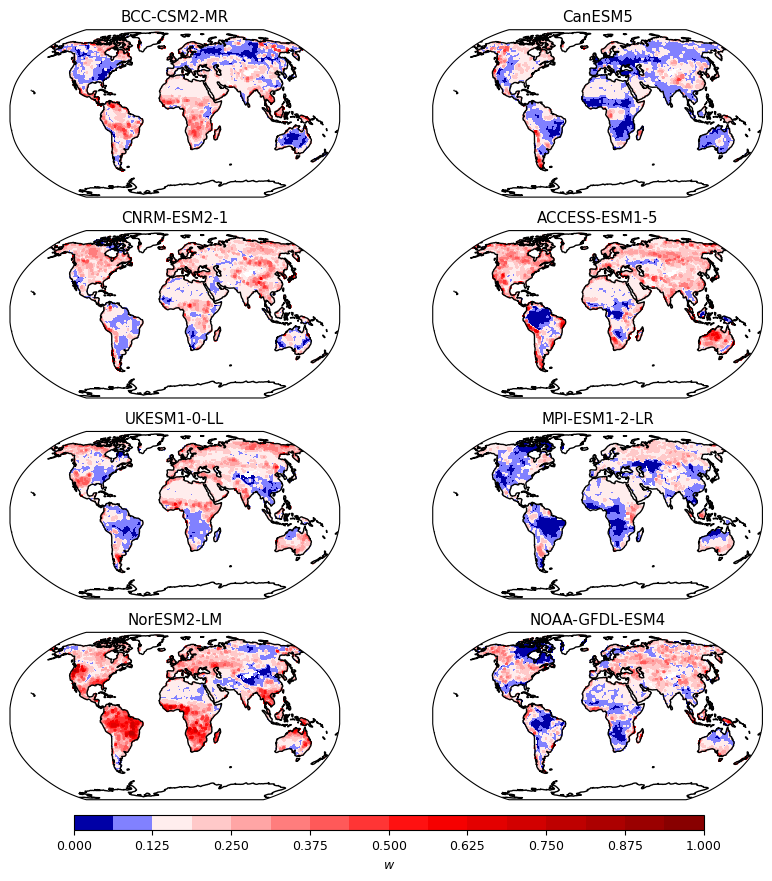

In [4]:
plt.rcParams.update({'font.size':9})
fig,ax=plt.subplots(ncols=2,nrows=4,figsize=[10,10],subplot_kw={"projection": ccrs.Robinson()})
#fig.suptitle('CMIP6-FLUXCOM-X (NEP)')     
xxl=list(wnep.keys()); xxw=[]    
a=-1
levels=np.linspace(0,1,(len(xxl))*2+1)
divnorm=colors.TwoSlopeNorm(vmin=0.,vcenter=1/len(xxl),vmax=1)
#pcolormesh(your_data, cmap="coolwarm", norm=divnorm)
for j in range(len(xxl)):
#for j in range(1):
    if j/2==int(j/2):a=a+1
    xxv=wnep[xxl[j]]
    pt=ax[a,j-2*a].contourf(xxv.lon,xxv.lat,xxv,transform=ccrs.PlateCarree(),cmap='seismic',levels=levels,norm=divnorm)
    ax[a,j-2*a].coastlines()
    ax[a,j-2*a].set_title(modelnep[j])
    #cbar=plt.colorbar(pt,shrink=0.8,orientation='horizontal',ax=ax[a,j-2*a],pad=0.04,aspect=30,format=tkr.FormatStrFormatter('%.1g'))
    for c in pt.collections:c.set_edgecolor("face")
cax=plt.axes([0.2, 0.08, 0.63, 0.015])
cbar=plt.colorbar(pt,cax,shrink=0.8,orientation='horizontal',aspect=10,label=r'$w$')
fig.savefig('/home/_ehoyos/cmip6stop/CS/Figures/Weights/CMIP6_FLUXCOM_weights.pdf')



# plt.rcParams.update({'font.size':9})
# fig,ax=plt.subplots(ncols=2,nrows=4,figsize=[10,8*np.sqrt(2)],subplot_kw={"projection": ccrs.Robinson()})
# #fig.suptitle('CMIP6-CarboScope (NBP)')     
# xxl=list(Dnep.keys()); xxw=[]    
# a=-1
# vmin=0
# vmax=900
# levels=np.linspace(vmin,vmax,11)

# #for j in range(len(xxl)):
# for j in range(8):
#     if j/2==int(j/2):a=a+1
#     xxv=Dnep[xxl[j]]
#     pt=ax[a,j-2*a].contourf(xxv.lon,xxv.lat,xxv,transform=ccrs.PlateCarree(),cmap="PuBu_r",levels=levels)
#     ax[a,j-2*a].coastlines()
#     ax[a,j-2*a].set_title(modelnep[j])
#    # cbar=plt.colorbar(pt,shrink=0.8,orientation='horizontal',ax=ax[a,j-2*a],pad=0.04,aspect=30)



## CMIP6-CarboScope

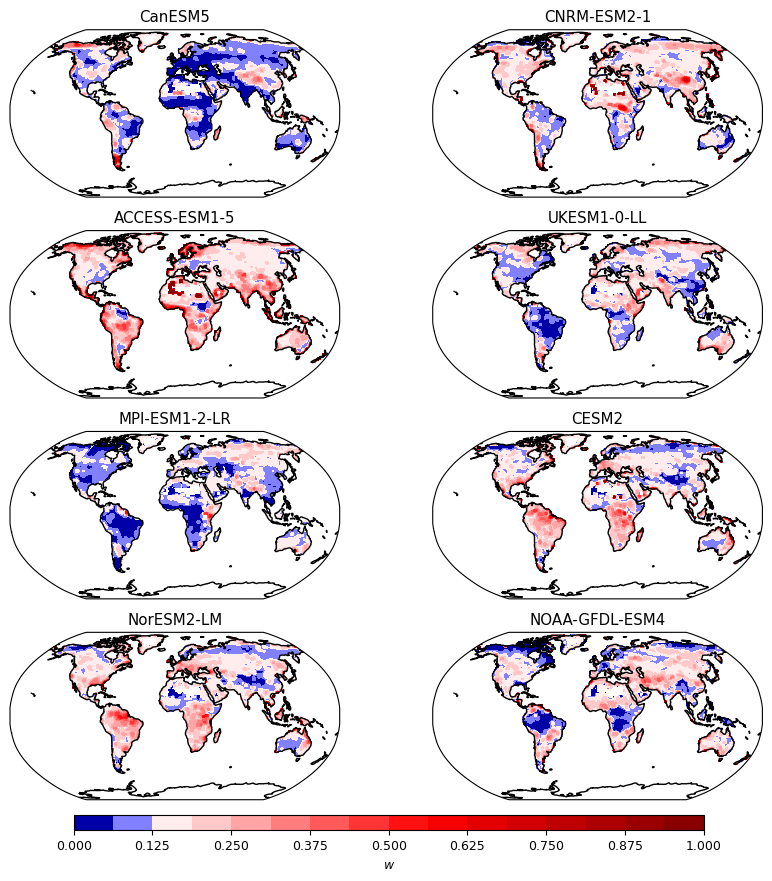

In [5]:
plt.rcParams.update({'font.size':9})
fig,ax=plt.subplots(ncols=2,nrows=4,figsize=[10,10],subplot_kw={"projection": ccrs.Robinson()})
#fig.suptitle('CMIP6-CarboScope (NBP)')     
xxl=list(wnbp.keys()); xxw=[]    
a=-1
levels=np.linspace(0,1,(len(xxl))*2+1)
divnorm=colors.TwoSlopeNorm(vmin=0.,vcenter=1/len(xxl),vmax=1)
for j in range(len(xxl)):
#for j in range(1):
    if j/2==int(j/2):a=a+1
    xxv=wnbp[xxl[j]]
    pt=ax[a,j-2*a].contourf(xxv.lon,xxv.lat,xxv,transform=ccrs.PlateCarree(),cmap="seismic",levels=levels,norm=divnorm)
    ax[a,j-2*a].coastlines()
    ax[a,j-2*a].set_title(modelnbp[j])
    #cbar=plt.colorbar(pt,shrink=0.8,orientation='horizontal',ax=ax[a,j-2*a],pad=0.04,aspect=30,format=tkr.FormatStrFormatter('%.1g'))
    for c in pt.collections:c.set_edgecolor("face")
cax=plt.axes([0.2, 0.08, 0.63, 0.015])
cbar=plt.colorbar(pt,cax,shrink=0.8,orientation='horizontal',aspect=10,label=r'$w$')
fig.savefig('/home/_ehoyos/cmip6stop/CS/Figures/Weights/CMIP6_CarboScope_weights.pdf')

### $\mathcal{A}_m$

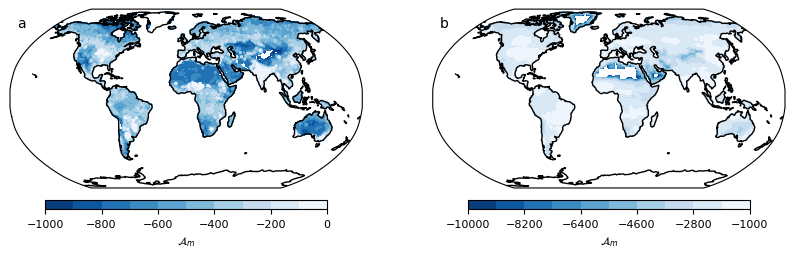

In [6]:
plt.rcParams.update({'font.size':8})
fig,ax=plt.subplots(ncols=2,nrows=1,figsize=[10,3],subplot_kw={"projection": ccrs.Robinson()})

#NEP
levels=np.linspace(-1000,0,11)
divnorm=colors.TwoSlopeNorm(vmin=-1000,vcenter=-500,vmax=0)
pt=ax[0].contourf(Amnep.lon,Amnep.lat,Amnep[list(Amnep.variables)[-1]],transform=ccrs.PlateCarree(),cmap="Blues_r",levels=levels,norm=divnorm)
ax[0].coastlines()
cbar=plt.colorbar(pt,shrink=0.8,orientation='horizontal',ax=ax[0],pad=0.05,aspect=30,label=r'$\mathcal{A}_m$') # log[(kgC m$^{-2}$yr$^{-1}$)$^{2}$]
for c in pt.collections:c.set_edgecolor("face")
plt.text(0.02,0.9,'a', transform=ax[0].transAxes,fontsize=10)

#NBP
levels=np.linspace(-10000,-1000,11)
divnorm=colors.TwoSlopeNorm(vmin=-10000,vcenter=-5500,vmax=-1000)  
pt=ax[1].contourf(Amnbp.lon,Amnbp.lat,Amnbp[list(Amnbp.variables)[-1]],transform=ccrs.PlateCarree(),cmap="Blues_r",levels=levels,norm=divnorm)
ax[1].coastlines()
cbar=plt.colorbar(pt,shrink=0.8,orientation='horizontal',ax=ax[1],pad=0.05,aspect=30,label=r'$\mathcal{A}_m$') #  log [(kgC m$^{-2}$yr$^{-1}$)$^{2}$]
for c in pt.collections:c.set_edgecolor("face")
plt.text(0.02,0.9,'b', transform=ax[1].transAxes,fontsize=10)    

fig.savefig('/home/_ehoyos/cmip6stop/CS/Figures/Weights/Amin.pdf',bbox_inches='tight')

### NEP and NBP time series of each model and the ensembles as arithmetic mean and weighted mean

In [7]:
# Read sigma files and reshape the datasets. 
# NBP
#sigma_nbp=xr.open_dataset('~/ResultsCS/Weights/nbpCMIP6_ob_CarboScope_std_ensemble.nc')
sigma_nbp=xr.open_dataset('~/ResultsCS/Weights/nbpCMIP6_ob_CarboScope_sigma2_ensemble_v3.nc')
sigmac1_nbp=xr.open_dataset('~/ResultsCS/Weights/nbpCMIP6_ob_CarboScope_sigma2c1_ensemble_v3.nc')
sigmaa_nbp=xr.open_dataset('~/ResultsCS/Weights/nbpCMIP6_ob_CarboScope_sigma2_arithm_v3.nc')
sigmaac1_nbp=xr.open_dataset('~/ResultsCS/Weights/nbpCMIP6_ob_CarboScope_sigma2c1_arithm_v3.nc')
sigma_nbp=sigma_nbp[list(sigma_nbp.variables)[-1]].to_dataset(name='sigmaw_nbp')
sigma_nbp=sigma_nbp.assign(sigmawc1_nbp=sigmac1_nbp[list(sigmac1_nbp.variables)[-1]])
sigma_nbp=sigma_nbp.assign(sigmaa_nbp=sigmaa_nbp[list(sigmaa_nbp.variables)[-1]])
sigma_nbp=sigma_nbp.assign(sigmaac1_nbp=sigmaac1_nbp[list(sigmaac1_nbp.variables)[-1]])

sigma_nbp=np.sqrt(sigma_nbp)
# #sigma_nbp=sigma_nbp.resample(time='Y').mean()
sigma_nbp["time"]=sigma_nbp["time"].astype("datetime64[ns]")

# sigma_nbp=sigma_nbp[list(sigma_nbp.variables)[0]]  
# sigma_nbp=sigma_nbp.T.transpose('time','lat','lon')
# sigma_nbp_xy=calc_spatial_integral(sigma_nbp)
# sigma_nbp_xy=sigma_nbp_xy.resample(time='Y').mean()

# NEP
sigma_nep=xr.open_dataset('~/ResultsCS/Weights/nepCMIP6_ob_FLUXCOM-X_sigma2_ensemble_v3.nc')
sigmac1_nep=xr.open_dataset('~/ResultsCS/Weights/nepCMIP6_ob_FLUXCOM-X_sigma2c1_ensemble_v3.nc')
sigmaa_nep=xr.open_dataset('~/ResultsCS/Weights/nepCMIP6_ob_FLUXCOM-X_sigma2_arithm_v3.nc')
sigmaac1_nep=xr.open_dataset('~/ResultsCS/Weights/nepCMIP6_ob_FLUXCOM-X_sigma2c1_arithm_v3.nc')
sigma_nep=sigma_nep[list(sigma_nep.variables)[-1]].to_dataset(name='sigmaw_nep')
sigma_nep=sigma_nep.assign(sigmawc1_nep=sigmac1_nep[list(sigmac1_nep.variables)[-1]])
sigma_nep=sigma_nep.assign(sigmaa_nep=sigmaa_nep[list(sigmaa_nep.variables)[-1]])
sigma_nep=sigma_nep.assign(sigmaac1_nep=sigmaac1_nep[list(sigmaac1_nep.variables)[-1]])

sigma_nep=np.sqrt(sigma_nep)
# #sigma_nep=sigma_nep.resample(time='Y').mean()
sigma_nep["time"]=sigma_nep["time"].astype("datetime64[ns]")

# sigma_nep=sigma_nep[list(sigma_nep.variables)[0]]  
# sigma_nep=sigma_nep.T.transpose('time','lat','lon')
# sigma_nep_xy=calc_spatial_integral(sigma_nep)
# sigma_nep_xy=sigma_nep_xy.resample(time='Y').mean()

### Variance of the weighted average

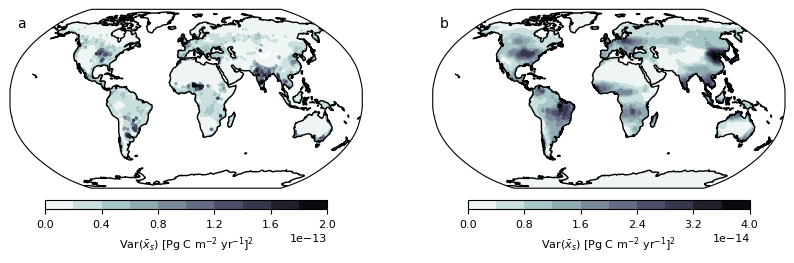

In [9]:
sigma_nep_models=xr.open_dataset('~/ResultsCS/Weights/nepCMIP6_ob_FLUXCOM-X_variance.nc')/1e12
sigma_nbp_models=xr.open_dataset('~/ResultsCS/Weights/nbpCMIP6_ob_CarboScope_variance.nc')/1e12


plt.rcParams.update({'font.size':8})
fig,ax=plt.subplots(ncols=2,nrows=1,figsize=[10,3],subplot_kw={"projection": ccrs.Robinson()})

#NEP
v=1/sigma_nep_models
v2=1/v.to_array().sum("variable")

levels=np.linspace(0,0.2/1e12,11)
divnorm=colors.TwoSlopeNorm(vmin=0,vcenter=0.1/1e12,vmax=0.2/1e12)
pt=ax[0].contourf(v2.lon,v2.lat,v2,transform=ccrs.PlateCarree(),cmap="bone_r",levels=levels,norm=divnorm)
ax[0].coastlines()
cbar=plt.colorbar(pt,shrink=0.8,orientation='horizontal',ax=ax[0],pad=0.05,aspect=30,label=r'Var($\bar{x}_{s}$) [Pg C m$^{-2}$ yr$^{-1}$]$^2$') # log[(kgC m$^{-2}$yr$^{-1}$)$^{2}$]
for c in pt.collections:c.set_edgecolor("face")
plt.text(0.02,0.9,'a', transform=ax[0].transAxes,fontsize=10)

# #NBP
v=1/sigma_nbp_models
v2=1/v.to_array().sum("variable")

levels=np.linspace(0,4/1e14,11)
divnorm=colors.TwoSlopeNorm(vmin=0/1e14,vcenter=2/1e14,vmax=4/1e14)
pt=ax[1].contourf(v2.lon,v2.lat,v2,transform=ccrs.PlateCarree(),cmap="bone_r",levels=levels,norm=divnorm)
ax[1].coastlines()
cbar=plt.colorbar(pt,shrink=0.8,orientation='horizontal',ax=ax[1],pad=0.05,aspect=30,label=r'Var($\bar{x}_{s}$) [Pg C m$^{-2}$ yr$^{-1}$]$^2$') # log[(kgC m$^{-2}$yr$^{-1}$)$^{2}$]
for c in pt.collections:c.set_edgecolor("face")
plt.text(0.02,0.9,'b', transform=ax[1].transAxes,fontsize=10)    

fig.savefig('/home/_ehoyos/cmip6stop/CS/Figures/Weights/Var.pdf',bbox_inches='tight')

In [88]:
sigma_nep

<xarray.Dataset>
Dimensions:       (lat: 180, lon: 360, time: 1980)
Coordinates:
  * lat           (lat) float32 -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon           (lon) float32 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
    type          |S4 ...
  * time          (time) datetime64[ns] 1850-01-01 1850-02-01 ... 2014-12-01
Data variables:
    sigmaw_nep    (lat, lon, time) float32 ...
    sigmawc1_nep  (lat, lon, time) float32 ...

0
1


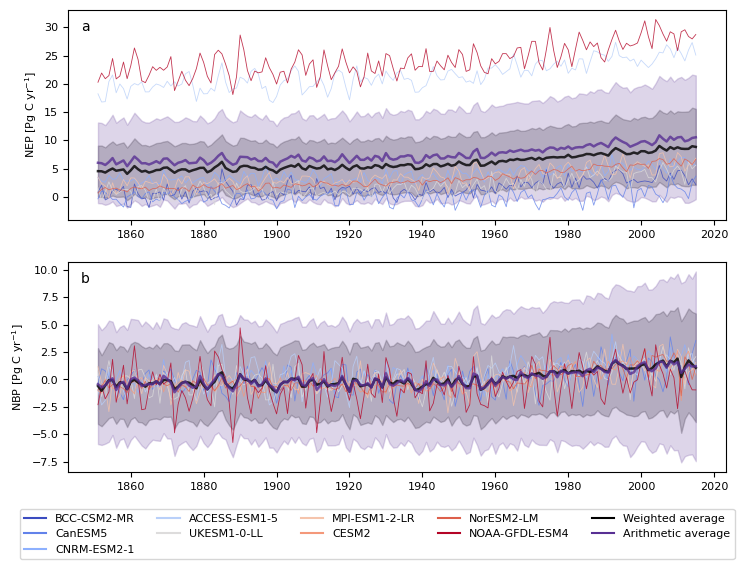

In [96]:
plt.rcParams.update({'font.size':8})
fig,ax=plt.subplots(ncols=1,nrows=2,figsize=[6*np.sqrt(2),6])

model=['BCC-CSM2-MR','CanESM5','CNRM-ESM2-1','ACCESS-ESM1-5','UKESM1-0-LL','MPI-ESM1-2-LR','CESM2','NorESM2-LM','NOAA-GFDL-ESM4','Ensemble']
modelf=['BCC-CSM2-MR','CanESM5','CNRM-ESM2-1','ACCESS-ESM1-5','UKESM1-0-LL','MPI-ESM1-2-LR','CESM2',
        'NorESM2-LM','NOAA-GFDL-ESM4','Weighted average','Arithmetic average']

varx=['nep','nbp']
varname=['NEP','NBP']
maxv=np.array([3.2e13,1e12])
minv=np.array([1e12,-6e12])
zones=['Global','Tropics','Mid_latitudes','High_latitudes']

cmap=plt.cm.coolwarm; color1=cmap(np.linspace(0,1,9))
cmap=plt.cm.Greys;color2=cmap(np.linspace(1,1,1))
cmap=plt.cm.Purples;color3=cmap(np.linspace(0.85,1,1))
colors2=np.vstack((color1,color2,color3))
cc=['a','b']  

#for j in range(len(varx)):
for j in range(2): # variables
    print(j)
    if j==0:
        colorf=np.delete(colors2,6,0)
        sigmaw=sigma_nep['sigmawc1_nep']/1e12
        sigmaa=sigma_nep['sigmaac1_nep']/1e12
    if j==1:
        colorf=np.delete(colors2,0,0)
        sigmaw=sigma_nbp['sigmawc1_nbp']/1e12
        sigmaa=sigma_nbp['sigmaac1_nbp']/1e12
    sigmaw=sigmaw.T.transpose('time','lat','lon'); sigmaa=sigmaa.T.transpose('time','lat','lon')
    sigmaw=calc_spatial_integral(sigmaw); sigmaa=calc_spatial_integral(sigmaa)
    sigmaw=sigmaw.resample(time='Y').mean(); sigmaa=sigmaa.resample(time='Y').mean()
    
    vv=xr.open_dataset('~/ResultsCS/variables_latzones/CMIP6_'+varx[j]+'_'+zones[0]+'.nc')
    vv=vv/1e12
    vv["time"]=vv["time"].astype("datetime64[ns]")
    
    #vv=vv.convert_calendar("noleap",align_on='year')
    w=list(vv.keys())
    mean=vv[w[0:-1]].to_array(dim='new').mean('new')
#     std=vv[w[0:-1]].to_array(dim='new').std('new')
    vv=vv.assign(amean=mean)
#; vv=vv.assign(astd=std)
    vv=vv.resample(time="Y").mean()
         
    w=list(vv.keys())
    for k in range(len(w)): 
        if k<=len(w)-3: lw=0.6
        else:lw=1.8
        ax[j].plot(vv.time,vv[w[k]],color=colorf[k],alpha=0.8,linewidth=lw)
        if k==len(w)-1:
            ax[j].fill_between(vv.time.values,vv[w[k]]-sigmaa,vv[w[k]]+sigmaa,color=colorf[k],alpha=0.2)
        if k==len(w)-2:
            ax[j].fill_between(vv.time.values,vv[w[k]]-sigmaw,vv[w[k]]+sigmaw,color=colorf[k],alpha=0.2)
    
    
    ax[j].set_ylabel(varname[j]+' [Pg C yr$^{-1}$]')
    plt.text(0.02,0.9,cc[j], transform=ax[j].transAxes,fontsize=10)  
    

    
    
        
# #     ax2=ax[i,-1].twinx() # instantiate a second axes that shares the same x-axis
# #     ax2.set_ylabel(zonesn[i],fontsize=12,rotation=270,labelpad=15)
# #     ax2.set_yticks([],[])
# # plt.subplots_adjust(wspace=0.23)

lines=[Line2D([0],[0],color=c,linewidth=1.5) for c in colors2]
plt.legend(lines,modelf,loc='upper center',bbox_to_anchor=(0.47,-0.15),fancybox=True, ncol=5)

fig.savefig('/home/_ehoyos/cmip6stop/CS/Figures/Weights/Time_series_NXP_c1.pdf',bbox_inches='tight')


### Plots without the arithmetic average becase it cannot include the variance term

In [51]:
sigma_nep_models=xr.open_dataset('~/ResultsCS/Weights/nepCMIP6_ob_FLUXCOM-X_variance.nc')
sigma_nbp_models=xr.open_dataset('~/ResultsCS/Weights/nbpCMIP6_ob_CarboScope_variance.nc')

# NEP
sigma_nep=xr.open_dataset('~/ResultsCS/Weights/nepCMIP6_ob_FLUXCOM-X_sigma2_ensemble_v3.nc')
sigmac1_nep=xr.open_dataset('~/ResultsCS/Weights/nepCMIP6_ob_FLUXCOM-X_sigma2c1_ensemble_v3.nc')
sigma_nep=sigma_nep[list(sigma_nep.variables)[-1]].to_dataset(name='sigmaw_nep')
sigma_nep=sigma_nep.assign(sigmawc1_nep=sigmac1_nep[list(sigmac1_nep.variables)[-1]])
sigma_nep["time"]=sigma_nep["time"].astype("datetime64[ns]")

v=1/sigma_nep_models
v2_nep=1/v.to_array().sum("variable")
sigma_nep_total=np.sqrt(sigma_nep['sigmawc1_nep']+v2_nep)

# NBP
sigma_nbp=xr.open_dataset('~/ResultsCS/Weights/nbpCMIP6_ob_CarboScope_sigma2_ensemble_v3.nc')
sigmac1_nbp=xr.open_dataset('~/ResultsCS/Weights/nbpCMIP6_ob_CarboScope_sigma2c1_ensemble_v3.nc')
sigma_nbp=sigma_nbp[list(sigma_nbp.variables)[-1]].to_dataset(name='sigmaw_nbp')
sigma_nbp=sigma_nbp.assign(sigmawc1_nbp=sigmac1_nbp[list(sigmac1_nbp.variables)[-1]])
sigma_nbp["time"]=sigma_nbp["time"].astype("datetime64[ns]")


v=1/sigma_nbp_models
v2_nbp=1/v.to_array().sum("variable")
sigma_nbp_total=np.sqrt(sigma_nbp['sigmawc1_nbp']+v2_nbp)


0
1


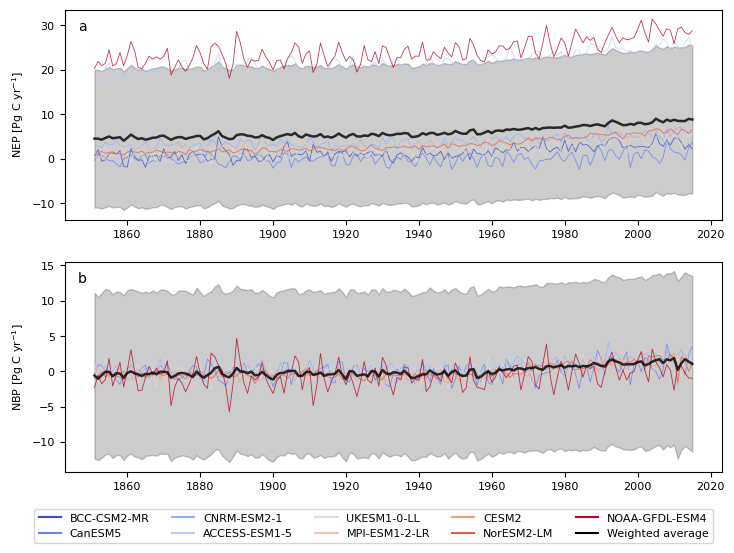

In [87]:
plt.rcParams.update({'font.size':8})
fig,ax=plt.subplots(ncols=1,nrows=2,figsize=[6*np.sqrt(2),6])

model=['BCC-CSM2-MR','CanESM5','CNRM-ESM2-1','ACCESS-ESM1-5','UKESM1-0-LL','MPI-ESM1-2-LR','CESM2','NorESM2-LM','NOAA-GFDL-ESM4','Ensemble']
modelf=['BCC-CSM2-MR','CanESM5','CNRM-ESM2-1','ACCESS-ESM1-5','UKESM1-0-LL','MPI-ESM1-2-LR','CESM2',
        'NorESM2-LM','NOAA-GFDL-ESM4','Weighted average','Arithmetic average']

varx=['nep','nbp']
varname=['NEP','NBP']
maxv=np.array([3.2e13,1e12])
minv=np.array([1e12,-6e12])
zones=['Global','Tropics','Mid_latitudes','High_latitudes']

cmap=plt.cm.coolwarm; color1=cmap(np.linspace(0,1,9))
cmap=plt.cm.Greys;color2=cmap(np.linspace(1,1,1))
colors2=np.vstack((color1,color2))
cc=['a','b']  


for j in range(2): # variables
    print(j)
    if j==0:
        colorf=np.delete(colors2,6,0)
        sigmaw=sigma_nep_total/1e12
    if j==1:
        colorf=np.delete(colors2,0,0)
        sigmaw=sigma_nbp_total/1e12
    sigmaw=sigmaw.where(sigmaw!= np.inf, np.nan)
    sigmaw=sigmaw.T.transpose('time','lat','lon')
    sigmaw=calc_spatial_integral(sigmaw)
    sigmaw=sigmaw.resample(time='Y').mean()
    
    vv=xr.open_dataset('~/ResultsCS/variables_latzones/CMIP6_'+varx[j]+'_'+zones[0]+'.nc')
    vv=vv/1e12
    vv["time"]=vv["time"].astype("datetime64[ns]")
    
    #vv=vv.convert_calendar("noleap",align_on='year')
    w=list(vv.keys())
    #mean=vv[w[0:-1]].to_array(dim='new').mean('new')
#     std=vv[w[0:-1]].to_array(dim='new').std('new')
#    vv=vv.assign(amean=mean)
#; vv=vv.assign(astd=std)
    vv=vv.resample(time="Y").mean()
         
    w=list(vv.keys())
    for k in range(len(w)): 
        if k<=len(w)-2: lw=0.6
        else:lw=1.8
        ax[j].plot(vv.time,vv[w[k]],color=colorf[k],alpha=0.8,linewidth=lw)
#         if k==len(w)-1:
#             ax[j].fill_between(vv.time.values,vv[w[k]]-sigmaa,vv[w[k]]+sigmaa,color=colorf[k],alpha=0.2)
        if k==len(w)-1:
            ax[j].fill_between(vv.time.values,vv[w[k]]-sigmaw,vv[w[k]]+sigmaw,color=colorf[k],alpha=0.2)
    
    
    ax[j].set_ylabel(varname[j]+' [Pg C yr$^{-1}$]')
    plt.text(0.02,0.9,cc[j], transform=ax[j].transAxes,fontsize=10)  
    

    
    
        
# # #     ax2=ax[i,-1].twinx() # instantiate a second axes that shares the same x-axis
# # #     ax2.set_ylabel(zonesn[i],fontsize=12,rotation=270,labelpad=15)
# # #     ax2.set_yticks([],[])
# # # plt.subplots_adjust(wspace=0.23)

lines=[Line2D([0],[0],color=c,linewidth=1.5) for c in colors2]
plt.legend(lines,modelf,loc='upper center',bbox_to_anchor=(0.47,-0.15),fancybox=True, ncol=5)

fig.savefig('/home/_ehoyos/cmip6stop/CS/Figures/Weights/Time_series_NXP_vf.pdf',bbox_inches='tight')


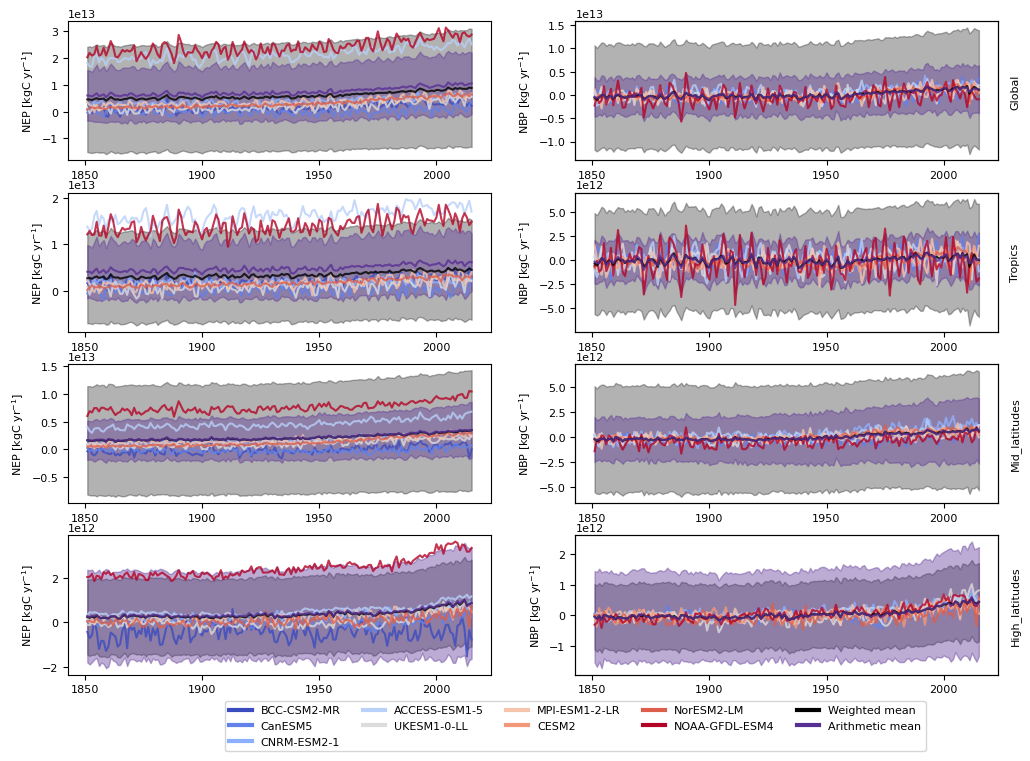

In [62]:
plt.rcParams.update({'font.size':8})
fig,ax=plt.subplots(ncols=2,nrows=4,figsize=[12,6*np.sqrt(2)])

model=['BCC-CSM2-MR','CanESM5','CNRM-ESM2-1','ACCESS-ESM1-5','UKESM1-0-LL','MPI-ESM1-2-LR','CESM2','NorESM2-LM','NOAA-GFDL-ESM4','Ensemble']
modelf=['BCC-CSM2-MR','CanESM5','CNRM-ESM2-1','ACCESS-ESM1-5','UKESM1-0-LL','MPI-ESM1-2-LR','CESM2',
        'NorESM2-LM','NOAA-GFDL-ESM4','Weighted mean','Arithmetic mean']

varx=['nep','nbp']
varname=['NEP','NBP']
maxv=np.array([3.2e13,1e12])
minv=np.array([1e12,-6e12])
zones=['Global','Tropics','Mid_latitudes','High_latitudes']

cmap=plt.cm.coolwarm; color1=cmap(np.linspace(0,1,9))
cmap=plt.cm.Greys;color2=cmap(np.linspace(1,1,1))
cmap=plt.cm.Purples;color3=cmap(np.linspace(0.85,1,1))
colors2=np.vstack((color1,color2,color3))
cc=['a','b']  

# #for j in range(len(varx)):
for j in range(2): # variables
#     print(j)
    if j==0:
        colorf=np.delete(colors2,6,0)
        sigma=sigma_nep
    if j==1:
        colorf=np.delete(colors2,0,0)
        sigma=sigma_nbp
    for i in range(len(zones)):
#     for i in range(1,2):
        vv=xr.open_dataset('~/ResultsCS/variables_latzones/CMIP6_'+varx[j]+'_'+zones[i]+'.nc')
        vv=vv.convert_calendar("noleap",align_on='year')
        # arithmetic mean
        w=list(vv.keys())
        mean=vv[w[0:-1]].to_array(dim='new').mean('new')
        std=vv[w[0:-1]].to_array(dim='new').std('new')
        vv=vv.assign(amean=mean); vv=vv.assign(astd=std)
        vv=vv.resample(time="Y").mean()
        w=list(vv.keys())
        
        # weighted ensemble
        if i==0:wmean=sigma # Global
        if i==1:mask=((sigma.lat <= 22.5)&(sigma.lat >= -22.5)) # Tropics
        if i==2:
            mask1=(sigma.lat > 22.5)&(sigma.lat < 55.0) # mid latitudes.
            mask2=(sigma.lat < -22.5) # mid latitudes.
        if i==3:mask=(sigma.lat >= 55.0) # high latitudes
        if i!=0:wmean=sigma.where(mask,drop=True)
   
        if k==2: 
            z1=sigma.where(mask1,drop=True);z2=sigma.where(mask2,drop=True)
            sigma_xy=calc_spatial_integral(z1)+calc_spatial_integral(z2) 
        else:sigma_xy=calc_spatial_integral(wmean)
        sigma_xyt=sigma_xy.resample(time='Y').mean()
        
        for k in range(len(w)-1): 
            ax[i,j].plot(vv.time,vv[w[k]],color=colorf[k],alpha=0.8)
            if k==len(w)-2:
                ax[i,j].fill_between(vv.time.values,vv[w[k]]-vv[w[k+1]],vv[w[k]]+vv[w[k+1]],color=colorf[k],alpha=0.4)
            if k==len(w)-3:
                ax[i,j].fill_between(vv.time.values,vv[w[k]]-sigma_xyt.values,vv[w[k]]+sigma_xyt.values,color=colorf[k],alpha=0.3)
        ax[i,j].set_ylabel(varname[j]+' [kgC yr$^{-1}$]')
#     plt.text(0.02,0.9,cc[j], transform=ax[j].transAxes,fontsize=10)  
        
        if j==1:
            ax2=ax[i,-1].twinx() # instantiate a second axes that shares the same x-axis
            ax2.set_ylabel(zones[i],fontsize=8,labelpad=5)
            ax2.set_yticks([],[])
plt.subplots_adjust(hspace=0.23)

lines=[Line2D([0],[0],color=c,linewidth=3) for c in colors2]
plt.legend(lines,modelf,loc='upper center',bbox_to_anchor=(0,-0.15),fancybox=True, ncol=5)

fig.savefig('/home/_ehoyos/cmip6stop/CS/Figures/Weights/Time_series_NXP_zones.pdf',bbox_inches='tight')


### Map correlation between NBP in CESM2 and NorESM2-LM

In [6]:
corr=xr.open_dataset('~/ResultsCS/nbp_CMIP6_CESM2_NORESM2_corr.nc')

/tmp/ipykernel_10991/453456148.py:9: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  for c in pt.collections:c.set_edgecolor("face")


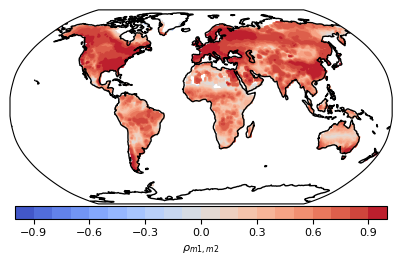

In [7]:
fig,ax=plt.subplots(figsize=[6,3],subplot_kw={"projection": ccrs.Robinson()})

#NEP
levels=np.linspace(-1,1,21)
divnorm=colors.TwoSlopeNorm(vmin=-1,vcenter=0,vmax=1)
pt=ax.contourf(corr.lon,corr.lat,corr[list(corr.variables)[-1]],transform=ccrs.PlateCarree(),cmap="coolwarm",levels=levels,norm=divnorm)
ax.coastlines()
cbar=plt.colorbar(pt,shrink=0.8,orientation='horizontal',ax=ax,pad=0.01,aspect=30,label=r'$\rho_{m1,m2}$')
for c in pt.collections:c.set_edgecolor("face")
fig.savefig('/home/_ehoyos/cmip6stop/CS/Figures/Weights/Corr_CESM_NorESM.pdf',bbox_inches='tight')

### Maps D values

#### CMIP6-FLUXCOM-X

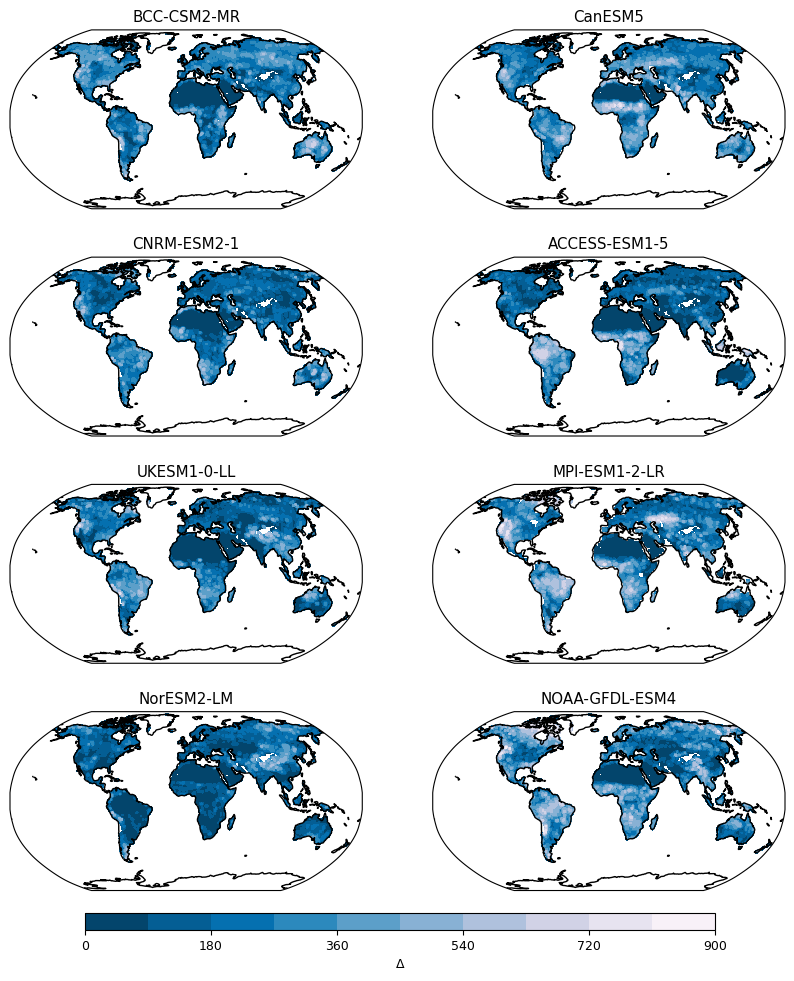

In [4]:
plt.rcParams.update({'font.size':9})
fig,ax=plt.subplots(ncols=2,nrows=4,figsize=[10,8*np.sqrt(2)],subplot_kw={"projection": ccrs.Robinson()})
#fig.suptitle('CMIP6-CarboScope (NBP)')     
xxl=list(Dnep.keys()); xxw=[]    
a=-1
vmin=0
vmax=900
levels=np.linspace(vmin,vmax,11)

#for j in range(len(xxl)):
for j in range(8):
    if j/2==int(j/2):a=a+1
    xxv=Dnep[xxl[j]]
    pt=ax[a,j-2*a].contourf(xxv.lon,xxv.lat,xxv,transform=ccrs.PlateCarree(),cmap="PuBu_r",levels=levels)
    ax[a,j-2*a].coastlines()
    ax[a,j-2*a].set_title(modelnep[j])
    for c in pt.collections:c.set_edgecolor("face")
   # cbar=plt.colorbar(pt,shrink=0.8,orientation='horizontal',ax=ax[a,j-2*a],pad=0.04,aspect=30)

cax=plt.axes([0.2, 0.08, 0.63, 0.015])
cbar=plt.colorbar(pt,cax,shrink=0.8,orientation='horizontal',aspect=10,label=r'$\Delta$')

fig.savefig('/home/_ehoyos/cmip6stop/CS/Figures/Weights/CMIP6_FLUXCOM-X_D.pdf')

#### CMIP6-CarboScope

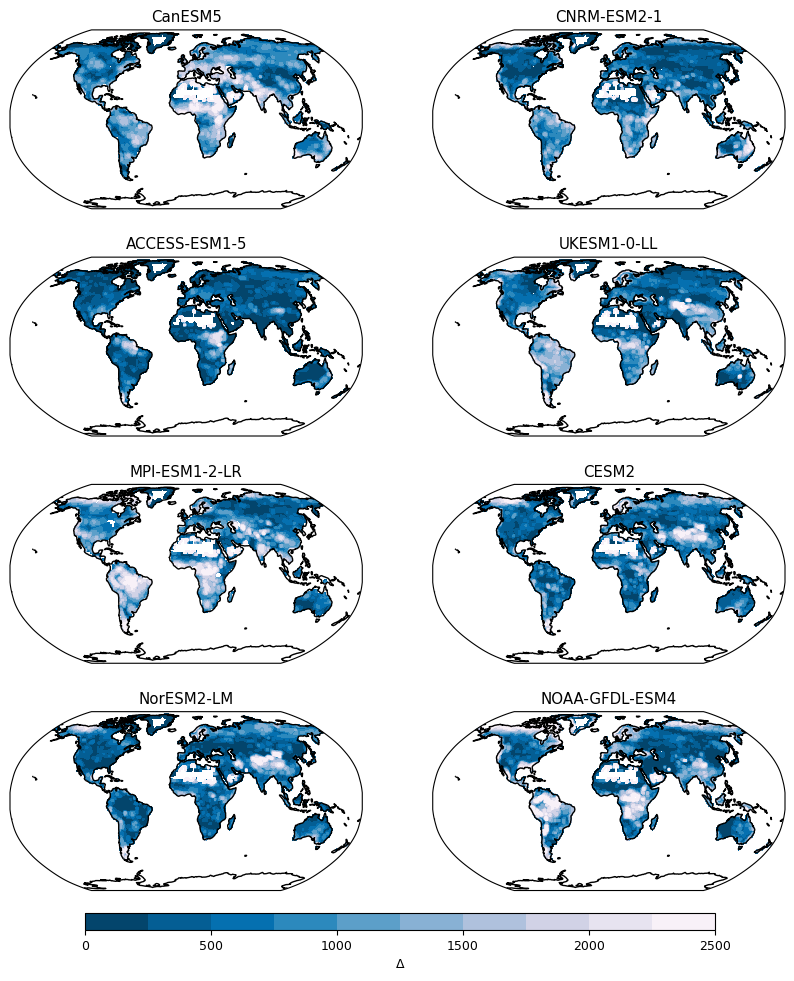

In [5]:
plt.rcParams.update({'font.size':9})
fig,ax=plt.subplots(ncols=2,nrows=4,figsize=[10,8*np.sqrt(2)],subplot_kw={"projection": ccrs.Robinson()})
#fig.suptitle('CMIP6-CarboScope (NBP)')     
xxl=list(Dnbp.keys()); xxw=[]    
a=-1
vmin=0
vmax=2500
levels=np.linspace(vmin,vmax,11)

for j in range(len(xxl)):
#for j in range(1):
    if j/2==int(j/2):a=a+1
    xxv=Dnbp[xxl[j]]
    pt=ax[a,j-2*a].contourf(xxv.lon,xxv.lat,xxv,transform=ccrs.PlateCarree(),cmap="PuBu_r",levels=levels)
    ax[a,j-2*a].coastlines()
    ax[a,j-2*a].set_title(modelnbp[j])
    for c in pt.collections:c.set_edgecolor("face")

cax=plt.axes([0.2, 0.08, 0.63, 0.015])
    #sm = plt.cm.ScalarMappable(cmap=cm, norm=plt.Normalize(vmin=1, vmax=2))
cbar=plt.colorbar(pt,cax,shrink=0.8,orientation='horizontal',aspect=10,label=r'$\Delta$')

fig.savefig('/home/_ehoyos/cmip6stop/CS/Figures/Weights/CMIP6_CarboScope_D.pdf')

array([   0.,  250.,  500.,  750., 1000., 1250., 1500., 1750., 2000.,
       2250., 2500.])